<a href="https://colab.research.google.com/github/evelynsaez/analisis_suicidios_antioquia/blob/data_zharita/Proyecto_Evelyn_Isamar_Yurany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = ('/content/Cantidad_anual_de_suicidios_reportados_en_el_Departamento_de_Antioquia_desde_2005_20251127.csv')
df = pd.read_csv(url)

df.head(5) #Se puede observar los primeros registros de la hoja de calculo

,NombreMunicipio,CodigoMunicipio,Ubicación,NombreRegion,CodigoRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,Suicidios,Poblacion total,"20,249",2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,Suicidios,Poblacion total,"2,690",0
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,Suicidios,Poblacion total,"3,816",0
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,Suicidios,Poblacion total,"27,155",0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,Suicidios,Poblacion total,"20,525",2


In [98]:
df.info


<bound method DataFrame.info of      NombreMunicipio  CodigoMunicipio                    Ubicación  \
0          Abejorral             5002   POINT (-75.427045 5.79145)   
1           Abriaquí             5004   POINT (-76.064563 6.63197)   
2         Alejandría             5021  POINT (-75.141258 6.376923)   
3              Amagá             5030   POINT (-75.703216 6.04063)   
4             Amalfi             5031  POINT (-75.075028 6.907385)   
...              ...              ...                          ...   
2495            Yalí             5885  POINT (-74.842107 6.675328)   
2496         Yarumal             5887  POINT (-75.416733 6.963321)   
2497         Yolombó             5890    POINT (-75.01183 6.59926)   
2498           Yondó             5893  POINT (-73.909599 7.007398)   
2499        Zaragoza             5895  POINT (-74.868261 7.492548)   

         NombreRegion  CodigoRegion  Anio CausaMortalidad  \
0             ORIENTE             7  2005       Suicidios   
1           OCCIDENTE             6  2005       Suicidios   
2             ORIENTE             7  2005       Suicidios   
3            SUROESTE             8  2005       Suicidios   
4            NORDESTE             4  2005       Suicidios   
...               ...           ...   ...             ...   
2495         NORDESTE             4  2024       Suicidios   
2496            NORTE             5  2024       Suicidios   
2497         NORDESTE             4  2024       Suicidios   
2498  MAGDALENA MEDIO             3  2024       Suicidios   
2499       BAJO CAUCA             2  2024       Suicidios   

     TipoPoblacionObjetivo NumeroPoblacionObjetivo  NumeroCasos  
0          Poblacion total                  20,249            2  
1          Poblacion total                   2,690            0  
2          Poblacion total                   3,816            0  
3          Poblacion total                  27,155            0  
4          Poblacion total                  20,525            2  
...                    ...                     ...          ...  
2495       Poblacion total                   8,091            0  
2496       Poblacion total                  44,457           12  
2497       Poblacion total                  24,023            1  
2498       Poblacion total                  20,727            3  
2499       Poblacion total                  26,207            2  

[2500 rows x 10 columns]>

In [99]:
df_numeros = df['NumeroPoblacionObjetivo'] = df['NumeroPoblacionObjetivo'].str.replace(',', '').astype(float).astype(int)
display(df)

,NombreMunicipio,CodigoMunicipio,Ubicación,NombreRegion,CodigoRegion,Anio,CausaMortalidad,TipoPoblacionObjetivo,NumeroPoblacionObjetivo,NumeroCasos
0,Abejorral,5002,POINT (-75.427045 5.79145),ORIENTE,7,2005,Suicidios,Poblacion total,20249,2
1,Abriaquí,5004,POINT (-76.064563 6.63197),OCCIDENTE,6,2005,Suicidios,Poblacion total,2690,0
2,Alejandría,5021,POINT (-75.141258 6.376923),ORIENTE,7,2005,Suicidios,Poblacion total,3816,0
3,Amagá,5030,POINT (-75.703216 6.04063),SUROESTE,8,2005,Suicidios,Poblacion total,27155,0
4,Amalfi,5031,POINT (-75.075028 6.907385),NORDESTE,4,2005,Suicidios,Poblacion total,20525,2
...,...,...,...,...,...,...,...,...,...,...
2495,Yalí,5885,POINT (-74.842107 6.675328),NORDESTE,4,2024,Suicidios,Poblacion total,8091,0
2496,Yarumal,5887,POINT (-75.416733 6.963321),NORTE,5,2024,Suicidios,Poblacion total,44457,12
2497,Yolombó,5890,POINT (-75.01183 6.59926),NORDESTE,4,2024,Suicidios,Poblacion total,24023,1
2498,Yondó,5893,POINT (-73.909599 7.007398),MAGDALENA MEDIO,3,2024,Suicidios,Poblacion total,20727,3


In [102]:
#Excluir el valle de aburra:

excluir = [
    'VALLE DE ABURRA',
]
df_cont = df[~df['NombreRegion'].isin(excluir)]

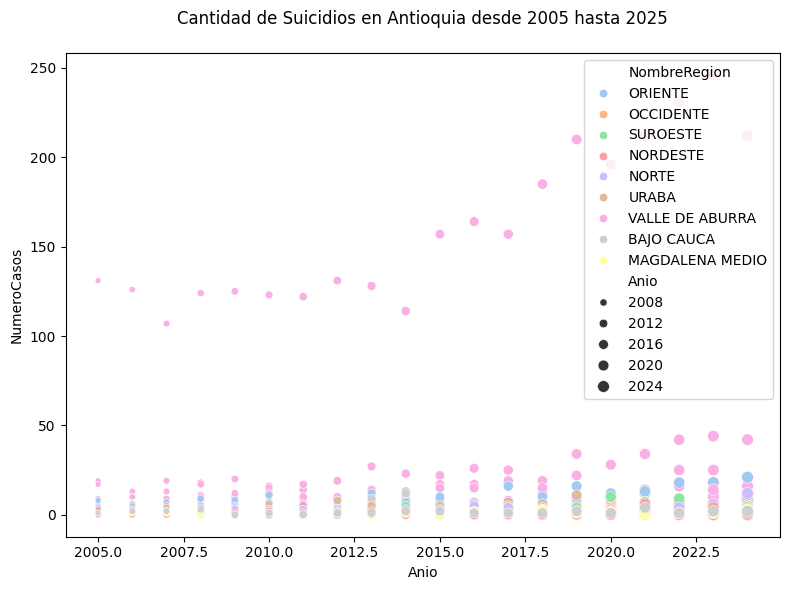

In [103]:
# Relación entre 'Ingresos' y 'Número de Emprendimientos', diferenciando si exporta
df = df[(df["Anio"] >= 2005) & (df["Anio"] <= 2024)]
suma_casos = df.groupby("Anio")["NumeroCasos"].sum().reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Anio',
    y='NumeroCasos',
    hue='NombreRegion',
    size='Anio',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025\n')
plt.tight_layout()
plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

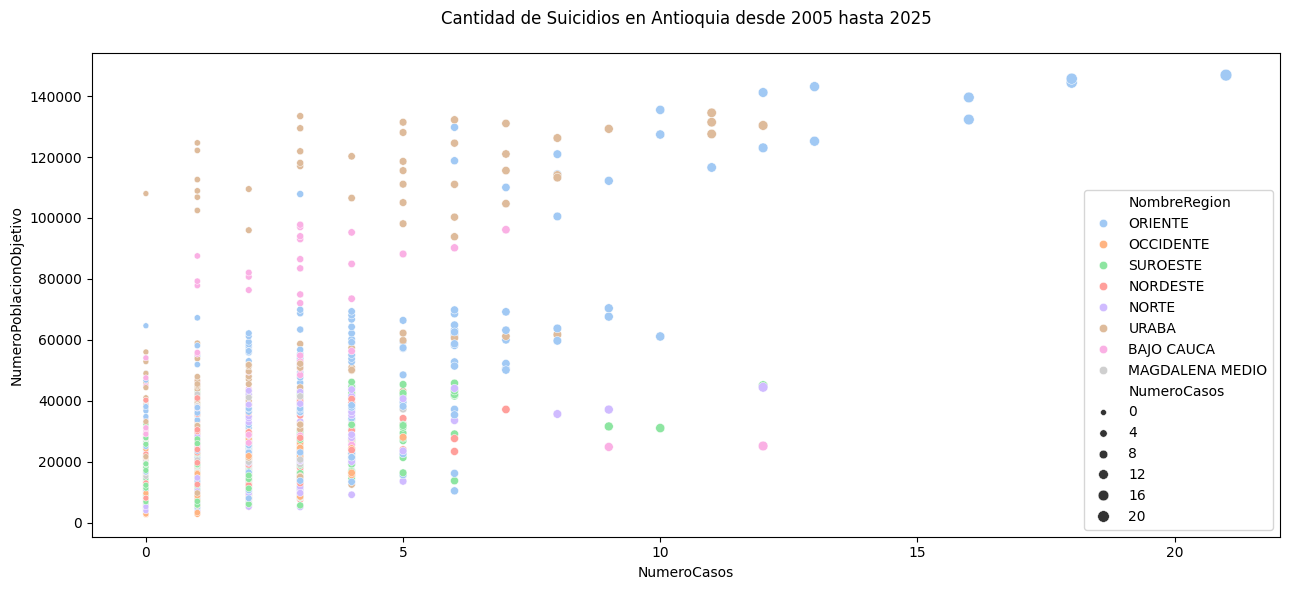

In [104]:
# Relación entre 'Ingresos' y 'Número de Emprendimientos', diferenciando si exporta
df = df[(df["Anio"] >= 2005) & (df["Anio"] <= 2024)]
suma_casos = df.groupby("Anio")["NumeroCasos"].sum().reset_index()

plt.figure(figsize=(13,6))
sns.scatterplot(
    data=df_cont,
    y='NumeroPoblacionObjetivo',
    x='NumeroCasos',
    hue='NombreRegion',
    size='NumeroCasos',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025\n')
plt.tight_layout()
plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

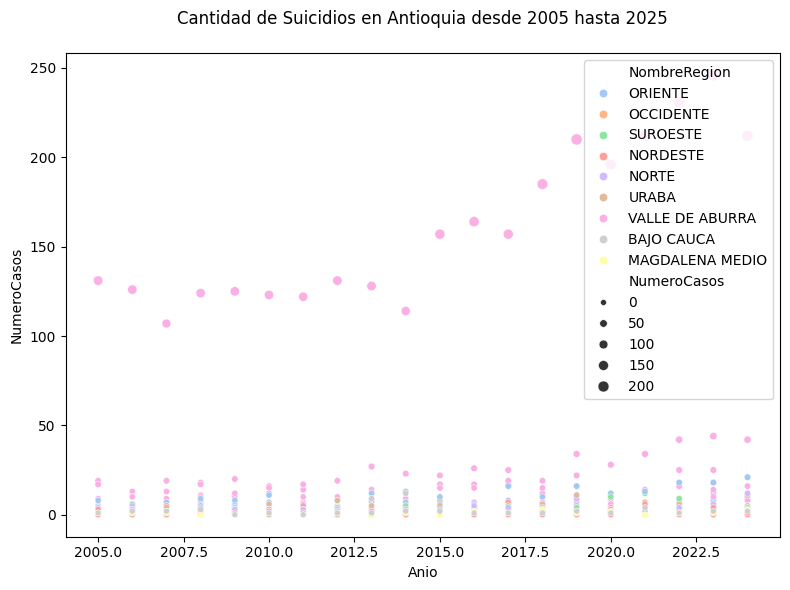

In [105]:
# Relación entre 'Ingresos' y 'Número de Emprendimientos', diferenciando si exporta
df = df[(df["Anio"] >= 2005) & (df["Anio"] <= 2024)]
suma_casos = df.groupby("Anio")["NumeroCasos"].sum().reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Anio',
    y='NumeroCasos',
    hue='NombreRegion',
    size='NumeroCasos',
    palette='pastel'

)

plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025\n')
plt.tight_layout()
plt.savefig('diagrama.png', dpi=300, transparent=True)
plt.show()

In [106]:
suma_casos

,Anio,NumeroCasos
0,2005,327
1,2006,328
2,2007,296
3,2008,338
4,2009,335
5,2010,326
6,2011,325
7,2012,329
8,2013,330
9,2014,323


In [107]:
df.info () #Se observa la información del dataframe (# registros, # nulos, tipo de info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NombreMunicipio          2500 non-null   object
 1   CodigoMunicipio          2500 non-null   int64 
 2   Ubicación                2500 non-null   object
 3   NombreRegion             2500 non-null   object
 4   CodigoRegion             2500 non-null   int64 
 5   Anio                     2500 non-null   int64 
 6   CausaMortalidad          2500 non-null   object
 7   TipoPoblacionObjetivo    2500 non-null   object
 8   NumeroPoblacionObjetivo  2500 non-null   int64 
 9   NumeroCasos              2500 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 195.4+ KB


In [108]:
df.isnull().sum() #Se observa cuantos valores nulos hay

,0
NombreMunicipio,0
CodigoMunicipio,0
Ubicación,0
NombreRegion,0
CodigoRegion,0
Anio,0
CausaMortalidad,0
TipoPoblacionObjetivo,0
NumeroPoblacionObjetivo,0
NumeroCasos,0


In [109]:
df['NumeroPoblacionObjetivo'] = pd.to_numeric(df['NumeroPoblacionObjetivo'], errors='coerce')

In [110]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NombreMunicipio          2500 non-null   object
 1   CodigoMunicipio          2500 non-null   int64 
 2   Ubicación                2500 non-null   object
 3   NombreRegion             2500 non-null   object
 4   CodigoRegion             2500 non-null   int64 
 5   Anio                     2500 non-null   int64 
 6   CausaMortalidad          2500 non-null   object
 7   TipoPoblacionObjetivo    2500 non-null   object
 8   NumeroPoblacionObjetivo  2500 non-null   int64 
 9   NumeroCasos              2500 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 195.4+ KB


In [111]:
df = df[(df["Anio"] >= 2005) & (df["Anio"] <= 2024)]
suma_casos = df.groupby("NombreRegion")["NumeroCasos"].sum().reset_index()

suma_casos

,NombreRegion,NumeroCasos
0,BAJO CAUCA,206
1,MAGDALENA MEDIO,126
2,NORDESTE,267
3,NORTE,372
4,OCCIDENTE,257
5,ORIENTE,948
6,SUROESTE,573
7,URABA,421
8,VALLE DE ABURRA,4746


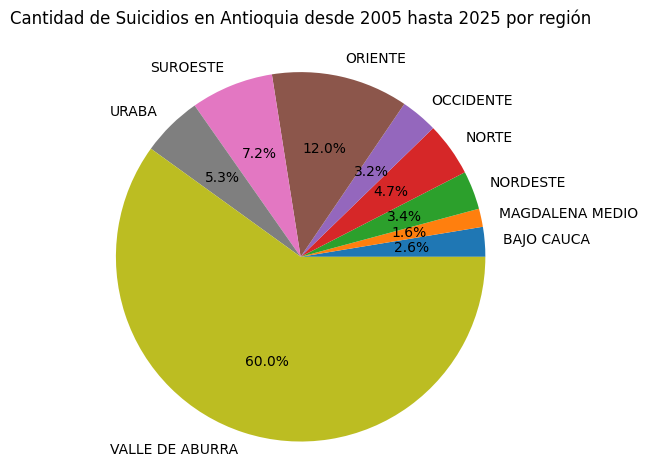

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

plt.pie(suma_casos['NumeroCasos'], labels=suma_casos['NombreRegion'], autopct="%0.1f%%")

plt.axis("equal")
plt.title('Cantidad de Suicidios en Antioquia desde 2005 hasta 2025 por región\n')
plt.tight_layout()

plt.show()


In [113]:
suma_columna_casos = df["NumeroCasos"].sum() #Suma los casos de suicidio en 20 años

print (suma_columna_casos)

7916


In [121]:
# Calcular estadísticas básicas (media, mediana, desviación estándar)
media = df["NumeroPoblacionObjetivo"].mean()
mediana = df["NumeroPoblacionObjetivo"].median()
desviacion_estandar = df["NumeroPoblacionObjetivo"].std()

print (f'''
El promedio es: {media}
La mediana: {mediana}
La desviación estandar: {desviacion_estandar}

''')


El promedio es: 49354.9096
La mediana: 16508.0
La desviación estandar: 212947.16329940135


